In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

In [ ]:
len(words)

In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

In [ ]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
X.shape, X.dtype, Y.shape, Y.dtype

In [ ]:
C = torch.randn((27, 2))

In [ ]:
X.shape

In [ ]:
X

In [ ]:
emb = C[X]
emb.shape

In [ ]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [ ]:
emb.view(-1,6).shape

In [ ]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [ ]:
h

In [ ]:
h.shape

In [ ]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [ ]:
logits = h @ W2 + b2

In [ ]:
logits.shape

In [ ]:
counts = logits.exp()

In [ ]:
prob = counts / counts.sum(1, keepdims=True)

In [ ]:
prob.shape

In [ ]:
loss = -prob[torch.arange(prob.shape[0]), Y].log().mean()
loss

In [ ]:
# ------------ now made respectable :) ---------------

In [ ]:
Xtr.shape, Ytr.shape # dataset

In [169]:
# Hypeparams

block_size = 5 # context length: how many characters do we take to predict the next one?

emb_cols = 10
embedings_feats = 2
layer1_units = 200
batch_size = 32

In [170]:
# build the dataset

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182400, 5]) torch.Size([182400])
torch.Size([22962, 5]) torch.Size([22962])
torch.Size([22784, 5]) torch.Size([22784])


In [171]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, embedings_feats), generator=g)
W1 = torch.randn((emb_cols, layer1_units), generator=g)
b1 = torch.randn(layer1_units, generator=g)
W2 = torch.randn((layer1_units, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [172]:
sum(p.nelement() for p in parameters) # number of parameters in total

7681

In [173]:
print(len(parameters))

5


In [174]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [175]:
lri = []
lossi = []
stepi = []

In [176]:
iter = 200000
alpha_decay_at = iter * .8
best_loss = 5000
best_params= parameters
for i in range(iter):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  # print(f'emb.shape: {emb.shape}')
  h = torch.tanh(emb.view(-1, emb_cols) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  if loss.item() < best_loss:
    best_loss = loss
    best_params = [p.detach().clone() for p in parameters]
    print(f'New best loss found: {loss}')
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < alpha_decay_at else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # if i % (iter /5000) == 0: 
  #   print(f'Iteration: {i}. Loss= {loss}')
  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())


#print(loss.item())

New best loss found: 18.80769920349121
New best loss found: 18.41220474243164
New best loss found: 15.71980094909668
New best loss found: 14.17192268371582
New best loss found: 13.030539512634277
New best loss found: 12.92081069946289
New best loss found: 11.816351890563965
New best loss found: 10.160672187805176
New best loss found: 7.923335075378418
New best loss found: 6.059614658355713
New best loss found: 6.0168070793151855
New best loss found: 5.074347972869873
New best loss found: 4.70788049697876
New best loss found: 4.475344181060791
New best loss found: 3.994664430618286
New best loss found: 3.587146043777466
New best loss found: 3.534332275390625
New best loss found: 3.517908811569214
New best loss found: 3.481513500213623
New best loss found: 3.3838651180267334
New best loss found: 3.3347880840301514
New best loss found: 3.3101422786712646
New best loss found: 3.2004153728485107
New best loss found: 3.037496328353882
New best loss found: 2.89091157913208
New best loss found

In [177]:
best_loss

tensor(1.3620, grad_fn=<NllLossBackward0>)

In [178]:
C, W1, b1, W2, b2 = best_params

In [179]:
print(len(parameters[4]))

27


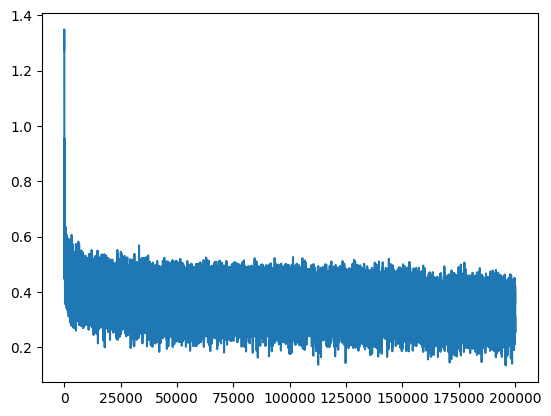

In [180]:
plt.plot(stepi, lossi)

In [181]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, emb_cols) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1630)

In [182]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, emb_cols) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1890)

In [183]:
emb = C[Xte]
h = torch.tanh(emb.view(-1,emb_cols) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Yte)
loss

tensor(2.1910)

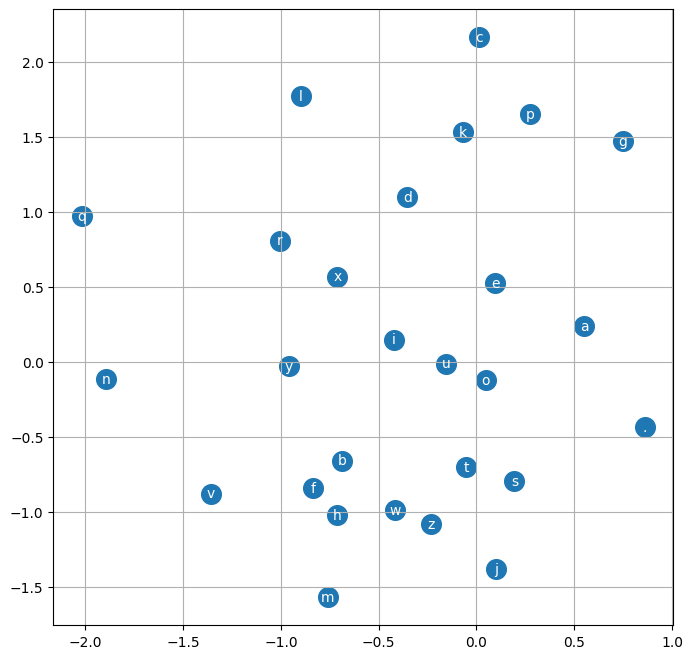

In [74]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [ ]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

In [ ]:
context = [0] * block_size
C[torch.tensor([context])].shape

In [ ]:


# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))